# Notebook 2 — Supervised: Predizione MAF per Cruise Control Adattivo

**Obiettivo:** dato lo stato corrente del veicolo e l'informazione "look-ahead" sulla strada nei prossimi N secondi (pendenza futura, accelerazione prevista), predire la portata d'aria istantanea (`MAF_g_per_sec`), proxy diretto del consumo di carburante.

**Narrativa:** un cruise control adattivo *predittivo* — diverso da quello tradizionale a velocità fissa — userebbe esattamente questo tipo di modello per simulare il consumo a diverse strategie di velocità e scegliere quella ottimale, conoscendo in anticipo l'orografia (da mappe).

**Tecniche del corso usate:**
- Pipeline e ColumnTransformer
- Regolarizzazione L1/L2 (Ridge, Lasso)
- Random Forest e XGBoost (gradient boosting)
- Split temporale per Trip (no leakage)
- K-Fold cross validation (TimeSeriesSplit / GroupKFold)
- Tuning iperparametri con Optuna (bayesiano)
- Metriche: MAE, MAPE, R²
- Feature importance

**Input:** `outputs/ved_enriched.parquet` (prodotto dal Notebook 1)

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')
RANDOM_STATE = 42

DATA = Path("./outputs/ved_enriched.parquet")
print(f"Carico {DATA}")
df = pd.read_parquet(DATA)
print(f"Shape: {df.shape}")

Carico outputs\ved_enriched.parquet
Shape: (17922869, 21)


## 2. Sampling stratificato per gestire il volume

Il dataset completo ha ~17M righe. Per il modeling iterativo (esplorazione, tuning) è più pratico lavorare su un sample stratificato. Manteniamo:
- proporzioni di EngineType
- copertura su tutti i veicoli
- copertura temporale completa

Strategia: prendiamo un campione di **trip interi** (non righe singole), per preservare la coerenza temporale all'interno di ogni viaggio.

In [2]:
# Lista di trip con relativo EngineType
trips_info = df.groupby(['VehId', 'Trip']).agg(
    EngineType=('EngineType', 'first'),
    n=('MAF_g_per_sec', 'size'),
    start=('Datetime', 'min')
).reset_index()

print(f"Trip totali: {len(trips_info):,}")
print("EngineType per trip:")
print(trips_info['EngineType'].value_counts())

# Campionamento stratificato: 30% dei trip per ogni EngineType
SAMPLE_FRAC = 0.3
sampled_trips = trips_info.groupby('EngineType', group_keys=False).apply(
    lambda g: g.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
)
print(f"\nTrip campionati: {len(sampled_trips):,}")

# Filtra il dataset
trip_keys = set(zip(sampled_trips['VehId'], sampled_trips['Trip']))
df['_key'] = list(zip(df['VehId'], df['Trip']))
df = df[df['_key'].isin(trip_keys)].drop(columns='_key').reset_index(drop=True)
print(f"Righe nel sample: {len(df):,}")

Trip totali: 26,285
EngineType per trip:
EngineType
ICE     14705
HEV      9327
PHEV     2253
Name: count, dtype: int64

Trip campionati: 7,886
Righe nel sample: 5,420,086


## 3. Feature Engineering — il cuore del progetto

**Idea chiave: feature "look-ahead".**
Un cruise control adattivo *predittivo* non guarda solo l'istante presente: usa informazioni sulla strada che sta per arrivare (da mappe, sensori, V2X). Simuliamo questo costruendo feature che guardano avanti nel tempo.

**Per ogni riga calcoliamo:**
1. **Slope futuro**: pendenza media nei prossimi 5s, 10s, 30s
2. **Velocità futura**: cosa farà il veicolo nei prossimi 5s, 10s
3. **Rolling statistiche passate**: velocità media e std negli ultimi 30s (proxy del tipo di strada percorsa)
4. **Feature temporali**: ora del giorno (effetto traffico), mese (effetto stagionale)

Queste vengono calcolate **all'interno di ogni trip**, mai across trip.

In [3]:
# Ordina per trip + tempo
df = df.sort_values(['VehId', 'Trip', 'Timestampms']).reset_index(drop=True)

grp = df.groupby(['VehId', 'Trip'], group_keys=False)

# Feature passate (rolling TRAILING, finestra all'indietro = già viste)
df['speed_roll30s_mean'] = grp['Vehicle_Speed_km_per_h'].rolling(30, min_periods=5).mean().reset_index(level=[0,1], drop=True)
df['speed_roll30s_std']  = grp['Vehicle_Speed_km_per_h'].rolling(30, min_periods=5).std().reset_index(level=[0,1], drop=True)
df['rpm_roll10s_mean']   = grp['Engine_RPM_RPM'].rolling(10, min_periods=3).mean().reset_index(level=[0,1], drop=True)

# Feature look-ahead: media dei PROSSIMI n campioni (i+1 .. i+n).
# IMPORTANTE: pandas .rolling(n) di default e' una finestra TRAILING (all'indietro).
# Per guardare davvero in avanti serve un FixedForwardWindowIndexer, altrimenti
# si finisce per mediare valori passati (bug che svuoterebbe di senso il look-ahead).
from pandas.api.indexers import FixedForwardWindowIndexer

def lookahead_mean(s, n):
    """Media dei prossimi n valori: shift(-1) esclude il punto corrente,
    la finestra forward prende s[i+1], ..., s[i+n]."""
    idx = FixedForwardWindowIndexer(window_size=n)
    return s.shift(-1).rolling(window=idx, min_periods=2).mean()

df['slope_future_5']  = grp['slope'].apply(lambda s: lookahead_mean(s, 5))
df['slope_future_10'] = grp['slope'].apply(lambda s: lookahead_mean(s, 10))
df['slope_future_30'] = grp['slope'].apply(lambda s: lookahead_mean(s, 30))

df['speed_future_5']  = grp['Vehicle_Speed_km_per_h'].apply(lambda s: lookahead_mean(s, 5))
df['speed_future_10'] = grp['Vehicle_Speed_km_per_h'].apply(lambda s: lookahead_mean(s, 10))

# Variazione di velocità prevista nei prossimi 5 campioni
df['speed_delta_future_5'] = df['speed_future_5'] - df['Vehicle_Speed_km_per_h']

# Feature temporali
df['hour'] = df['Datetime'].dt.hour
df['month'] = df['Datetime'].dt.month
df['dow'] = df['Datetime'].dt.dayofweek

# Cleanup NaN dei bordi (prime/ultime righe di ogni trip)
before = len(df)
df = df.dropna(subset=[
    'speed_roll30s_mean', 'speed_roll30s_std', 'rpm_roll10s_mean',
    'slope_future_5', 'slope_future_10', 'slope_future_30',
    'speed_future_5', 'speed_future_10', 'speed_delta_future_5'
]).reset_index(drop=True)
print(f"Dopo rimozione bordi: {len(df):,} righe ({before-len(df):,} rimosse)")

Dopo rimozione bordi: 5,372,770 righe (47,316 rimosse)


### 3.1 Nota sul data leakage

**Attenzione:** stiamo usando feature "future" (slope nei prossimi 30s) per predire una variabile **istantanea** (MAF al tempo $t$). Non è data leakage — al contrario, è il punto del progetto: un cruise control adattivo *ha* accesso a queste informazioni (le mappe gli dicono cosa c'è davanti). Il MAF al tempo $t$ però **non viene mai usato per costruire le feature**, solo come target.

Quello che invece sarebbe leakage:
- usare MAF medio nei prossimi N secondi come feature → NO
- usare statistiche aggregate del trip intero (es. MAF medio del trip) → NO
- usare la posizione finale o duration del trip → NO

Tutte queste sono state evitate.

## 4. Definizione del target e delle feature

Target: `MAF_g_per_sec`.
Avremmo potuto usare `log_MAF` per stabilità, ma preferiamo predire la quantità fisica direttamente e valutare in unità interpretabili (g/s).

In [4]:
TARGET = 'MAF_g_per_sec'

FEATURES_NUM = [
    # Stato istantaneo
    'Vehicle_Speed_km_per_h', 'accel_kmh_s', 'Engine_RPM_RPM',
    'Absolute_Load_pct', 'slope', 'OAT_DegC',
    # Rolling passato
    'speed_roll30s_mean', 'speed_roll30s_std', 'rpm_roll10s_mean',
    # Look-ahead (CHIAVE DEL PROGETTO)
    'slope_future_5', 'slope_future_10', 'slope_future_30',
    'speed_future_5', 'speed_future_10', 'speed_delta_future_5',
    # Vehicle
    'Generalized_Weight',
    # Temporal
    'hour', 'month', 'dow'
]
FEATURES_CAT = ['EngineType']

GROUP_COL = 'VehId'  # per group split

print(f"Numeriche: {len(FEATURES_NUM)}, Categoriche: {len(FEATURES_CAT)}")

Numeriche: 19, Categoriche: 1


## 5. Split train / test — split temporale per Trip

**Regola fondamentale per dati temporali:** mai mescolare righe dello stesso trip tra train e test. Mai usare trip futuri per addestrare e prevedere trip passati.

Strategia: ordiniamo i trip per data di inizio, prendiamo l'80% più vecchio per train, il 20% più recente per test. Questo simula il caso reale: si addestra su dati storici e si predice sul futuro.

In [5]:
trip_start = df.groupby(['VehId', 'Trip'])['Datetime'].min().sort_values()
n_train = int(len(trip_start) * 0.8)
train_trips = set(zip(trip_start.iloc[:n_train].index.get_level_values(0),
                       trip_start.iloc[:n_train].index.get_level_values(1)))
test_trips  = set(zip(trip_start.iloc[n_train:].index.get_level_values(0),
                       trip_start.iloc[n_train:].index.get_level_values(1)))

df['_key'] = list(zip(df['VehId'], df['Trip']))
train_df = df[df['_key'].isin(train_trips)].drop(columns='_key').reset_index(drop=True)
test_df  = df[df['_key'].isin(test_trips)].drop(columns='_key').reset_index(drop=True)
df = df.drop(columns='_key')

X_train, y_train = train_df[FEATURES_NUM + FEATURES_CAT], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES_NUM + FEATURES_CAT],  test_df[TARGET]
groups_train = train_df[GROUP_COL]

print(f"Train: {len(X_train):,} righe ({len(train_trips)} trip)")
print(f"Test:  {len(X_test):,} righe ({len(test_trips)} trip)")
print(f"Train period: {train_df['Datetime'].min()} → {train_df['Datetime'].max()}")
print(f"Test period:  {test_df['Datetime'].min()} → {test_df['Datetime'].max()}")

Train: 4,277,225 righe (6308 trip)
Test:  1,095,545 righe (1578 trip)
Train period: 2017-11-01 00:25:23.456955 → 2018-08-04 12:42:58.710938
Test period:  2018-08-04 12:47:54.023438 → 2018-11-10 11:58:38.261719


## 6. Pipeline e ColumnTransformer

Usiamo `ColumnTransformer` per applicare:
- `StandardScaler` alle feature numeriche (necessario per Ridge/Lasso, opzionale per alberi)
- `OneHotEncoder` a `EngineType`

Il tutto dentro una Pipeline che poi si combina con il modello. Questo blinda contro il data leakage: scaler e encoder vengono fittati **solo** sul training, e applicati identicamente al test.

In [6]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), FEATURES_CAT)
])

print("Preprocessor pronto.")

Preprocessor pronto.


## 7. Baseline 1 — Predizione costante (media globale)

Una baseline triviale per avere un riferimento. Se un modello sofisticato non batte questo, c'è qualcosa che non va.

In [7]:
y_pred_mean = np.full(len(y_test), y_train.mean())

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    # mape: evita div by zero filtrando target > 0.5 g/s
    mask = y_true > 0.5
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:25s}  MAE={mae:6.3f}  RMSE={rmse:6.3f}  MAPE={mape:6.2f}%  R²={r2:6.3f}")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

results = []
results.append(report("Baseline (mean)", y_test, y_pred_mean))

Baseline (mean)            MAE= 8.040  RMSE=10.361  MAPE=210.64%  R²=-0.001


## 8. Modello 1 — Ridge Regression (regolarizzata L2)

Primo modello vero: regressione lineare con regolarizzazione L2. Lo Standardscaler nella pipeline è essenziale (Ridge è sensibile alla scala).

In [8]:
pipe_ridge = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

pipe_ridge.fit(X_train, y_train)
y_pred = pipe_ridge.predict(X_test)
results.append(report("Ridge (α=1)", y_test, y_pred))

Ridge (α=1)                MAE= 4.149  RMSE= 5.798  MAPE= 95.51%  R²= 0.686


## 9. Modello 2 — Lasso (regolarizzata L1)

Lasso può portare alcuni coefficienti esattamente a zero, fungendo da feature selection. Vediamo quali feature considera importanti.

In [9]:
pipe_lasso = Pipeline([
    ('prep', preprocessor),
    ('model', Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=10000))
])

pipe_lasso.fit(X_train, y_train)
y_pred = pipe_lasso.predict(X_test)
results.append(report("Lasso (α=0.01)", y_test, y_pred))

# Quali feature ha azzerato?
feature_names = (FEATURES_NUM
                 + list(pipe_lasso.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(FEATURES_CAT)))
lasso_coefs = pipe_lasso.named_steps['model'].coef_
zeroed = [f for f, c in zip(feature_names, lasso_coefs) if abs(c) < 1e-6]
print(f"\nFeature azzerate da Lasso: {len(zeroed)} / {len(feature_names)}")
if zeroed:
    print(zeroed)

Lasso (α=0.01)             MAE= 4.148  RMSE= 5.801  MAPE= 95.24%  R²= 0.686

Feature azzerate da Lasso: 5 / 21
['Vehicle_Speed_km_per_h', 'slope', 'slope_future_5', 'slope_future_10', 'speed_future_5']


## 10. Modello 3 — Random Forest

Ensemble di alberi addestrati in parallelo su sottoinsiemi del dataset. Cattura non-linearità e interazioni senza bisogno di feature engineering manuale. Limitiamo gli alberi per tenere il training sotto controllo.

In [10]:
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100, max_depth=15, min_samples_leaf=20,
        n_jobs=-1, random_state=RANDOM_STATE))
])

pipe_rf.fit(X_train, y_train)
y_pred = pipe_rf.predict(X_test)
results.append(report("Random Forest", y_test, y_pred))

Random Forest              MAE= 2.326  RMSE= 4.299  MAPE= 36.21%  R²= 0.828


## 11. Modello 4 — XGBoost (gradient boosting)

Stato dell'arte per dati tabellari. Boosting sequenziale di weak learner. Aspettiamoci la performance migliore.

In [11]:
pipe_xgb_default = Pipeline([
    ('prep', preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.1,
        n_jobs=-1, random_state=RANDOM_STATE,
        tree_method='hist'))
])

pipe_xgb_default.fit(X_train, y_train)
y_pred = pipe_xgb_default.predict(X_test)
results.append(report("XGBoost (default)", y_test, y_pred))

XGBoost (default)          MAE= 2.416  RMSE= 4.205  MAPE= 40.46%  R²= 0.835


## 12. Tuning iperparametri con Optuna (ottimizzazione bayesiana)

**Perché Optuna invece di GridSearch?** Optuna usa un modello bayesiano (TPE) che impara dai trial precedenti per scegliere dove provare i prossimi iperparametri. In budget limitato (50-100 trial) trova soluzioni migliori di Grid/Random.

**Cosa cerchiamo:** `n_estimators`, `max_depth`, `learning_rate`, `min_child_weight`, `subsample`, `colsample_bytree`, `reg_alpha` (L1), `reg_lambda` (L2).

**Cross validation:** usiamo **GroupKFold** raggruppando per VehId, in modo che lo stesso veicolo non finisca contemporaneamente in train e validation. Questo è il modo corretto di fare CV con dati temporali raggruppati per entità.

> ⚠️ Questo step richiede tempo. Sul sample ridotto, 50 trial ≈ 15-30 minuti. Se hai fretta, riduci `N_TRIALS`.

In [12]:
N_TRIALS = 50  # alza a 100+ per migliore qualità
N_SPLITS = 3   # cross-val folds (3 è un compromesso; 5 è più robusto ma 1.7× più lento)

# Sub-sample per il tuning, per velocità (usiamo il 30% del train)
tune_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train), size=int(len(X_train)*0.3), replace=False)
X_tune = X_train.iloc[tune_idx].reset_index(drop=True)
y_tune = y_train.iloc[tune_idx].reset_index(drop=True)
groups_tune = groups_train.iloc[tune_idx].reset_index(drop=True)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', xgb.XGBRegressor(
            **params, n_jobs=-1, random_state=RANDOM_STATE,
            tree_method='hist'))
    ])
    
    gkf = GroupKFold(n_splits=N_SPLITS)
    maes = []
    for tr_idx, va_idx in gkf.split(X_tune, y_tune, groups=groups_tune):
        pipe.fit(X_tune.iloc[tr_idx], y_tune.iloc[tr_idx])
        preds = pipe.predict(X_tune.iloc[va_idx])
        maes.append(mean_absolute_error(y_tune.iloc[va_idx], preds))
    return np.mean(maes)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n=== Best params ===")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest CV MAE: {study.best_value:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]


=== Best params ===
  n_estimators: 713
  max_depth: 11
  learning_rate: 0.010521159492444322
  min_child_weight: 3
  subsample: 0.9518600808858217
  colsample_bytree: 0.9135010863706037
  reg_alpha: 0.028439937821965064
  reg_lambda: 5.275969945964435

Best CV MAE: 2.5455


### 12.1 Visualizzazione del tuning

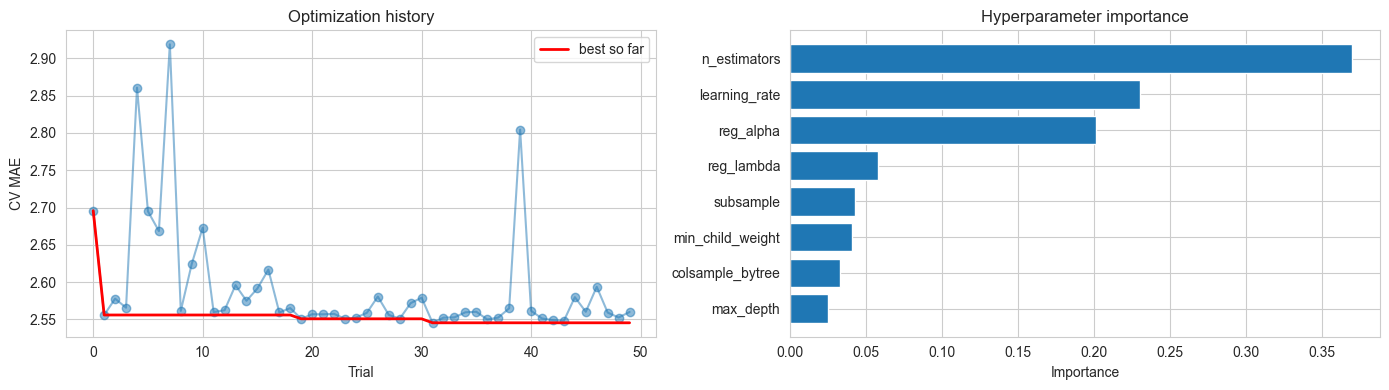

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Optimization history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], 'o-', alpha=0.5)
best_so_far = trials_df['value'].cummin()
axes[0].plot(trials_df['number'], best_so_far, 'r-', lw=2, label='best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV MAE')
axes[0].set_title('Optimization history')
axes[0].legend()

# Param importance
try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys())[::-1], list(importances.values())[::-1])
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Hyperparameter importance')
except Exception as e:
    print(f"Importance non calcolabile: {e}")

plt.tight_layout()
plt.show()

## 13. Modello finale — XGBoost tuned su tutto il training

Ora addestriamo l'XGBoost con i best params su **tutto** il training set, e valutiamo sul test set.

In [14]:
best_params = study.best_params

pipe_xgb_final = Pipeline([
    ('prep', preprocessor),
    ('model', xgb.XGBRegressor(
        **best_params, n_jobs=-1, random_state=RANDOM_STATE,
        tree_method='hist'))
])

pipe_xgb_final.fit(X_train, y_train)
y_pred_xgb = pipe_xgb_final.predict(X_test)
results.append(report("XGBoost (tuned)", y_test, y_pred_xgb))

XGBoost (tuned)            MAE= 2.287  RMSE= 4.107  MAPE= 36.50%  R²= 0.843


## 14. Confronto finale tra modelli

            model      MAE      RMSE       MAPE        R2
  Baseline (mean) 8.040030 10.360907 210.636330 -0.001179
      Ridge (α=1) 4.148606  5.797896  95.513515  0.686486
   Lasso (α=0.01) 4.148433  5.800988  95.240449  0.686152
    Random Forest 2.325892  4.298840  36.211611  0.827647
XGBoost (default) 2.416314  4.205370  40.464422  0.835061
  XGBoost (tuned) 2.287339  4.106852  36.496583  0.842698


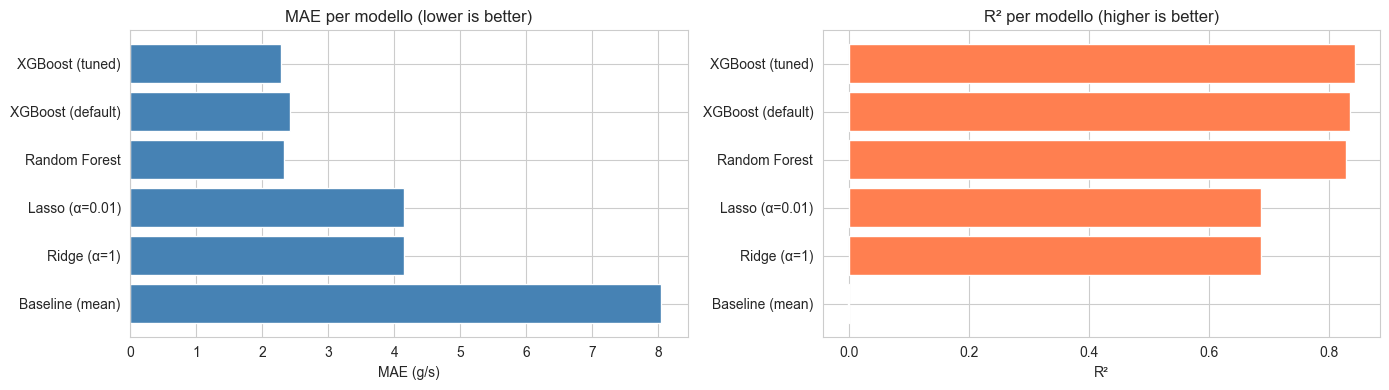

In [15]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(results_df['model'], results_df['MAE'], color='steelblue')
axes[0].set_xlabel('MAE (g/s)')
axes[0].set_title('MAE per modello (lower is better)')
axes[1].barh(results_df['model'], results_df['R2'], color='coral')
axes[1].set_xlabel('R²')
axes[1].set_title('R² per modello (higher is better)')
plt.tight_layout()
plt.show()

## 15. Feature Importance

Quali feature contano di più? Questo dice molto sul problema fisico. Aspettiamoci RPM, load e velocità in alto (sono fisicamente legati al consumo aria), e vogliamo verificare se le feature *look-ahead* (slope futuro) entrano nella classifica — se sì, è la prova che il modello ha imparato a sfruttare l'anticipazione.

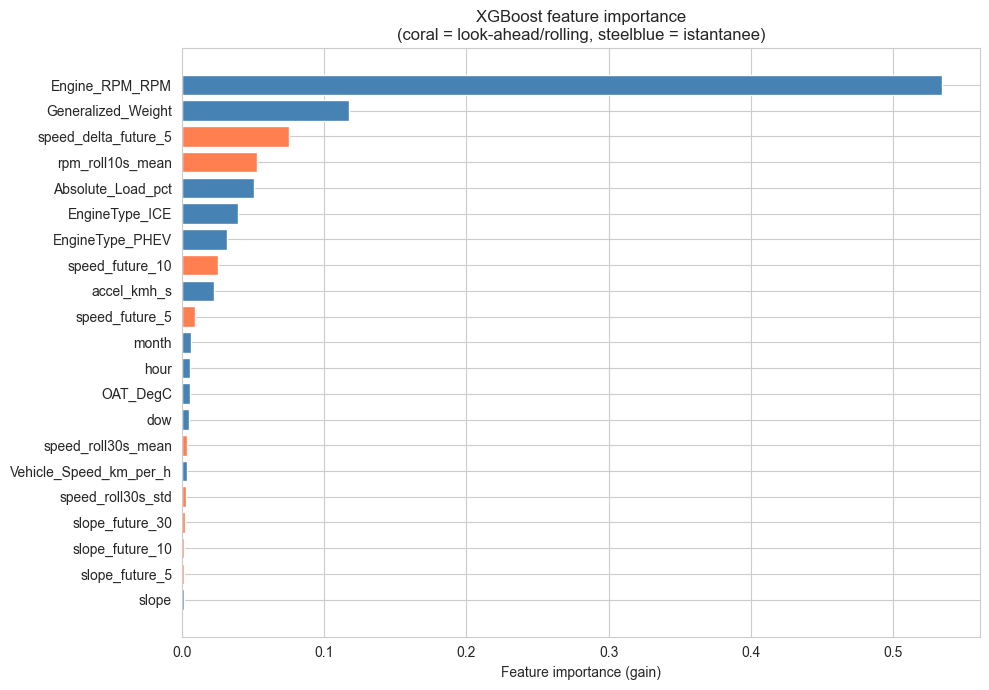


Top 10 feature:
             feature  importance
      Engine_RPM_RPM    0.534127
  Generalized_Weight    0.117784
speed_delta_future_5    0.075237
    rpm_roll10s_mean    0.052682
   Absolute_Load_pct    0.050888
      EngineType_ICE    0.039485
     EngineType_PHEV    0.031941
     speed_future_10    0.025509
         accel_kmh_s    0.022418
      speed_future_5    0.009424


In [16]:
model = pipe_xgb_final.named_steps['model']
feature_names_out = (FEATURES_NUM
                     + list(pipe_xgb_final.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(FEATURES_CAT)))

imp = pd.DataFrame({
    'feature': feature_names_out,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['coral' if 'future' in f or 'roll' in f else 'steelblue' for f in imp['feature']]
ax.barh(imp['feature'], imp['importance'], color=colors)
ax.set_xlabel('Feature importance (gain)')
ax.set_title('XGBoost feature importance\n(coral = look-ahead/rolling, steelblue = istantanee)')
plt.tight_layout()
plt.show()

print("\nTop 10 feature:")
print(imp.sort_values('importance', ascending=False).head(10).to_string(index=False))

## 16. Diagnostica: residui e predicted vs actual

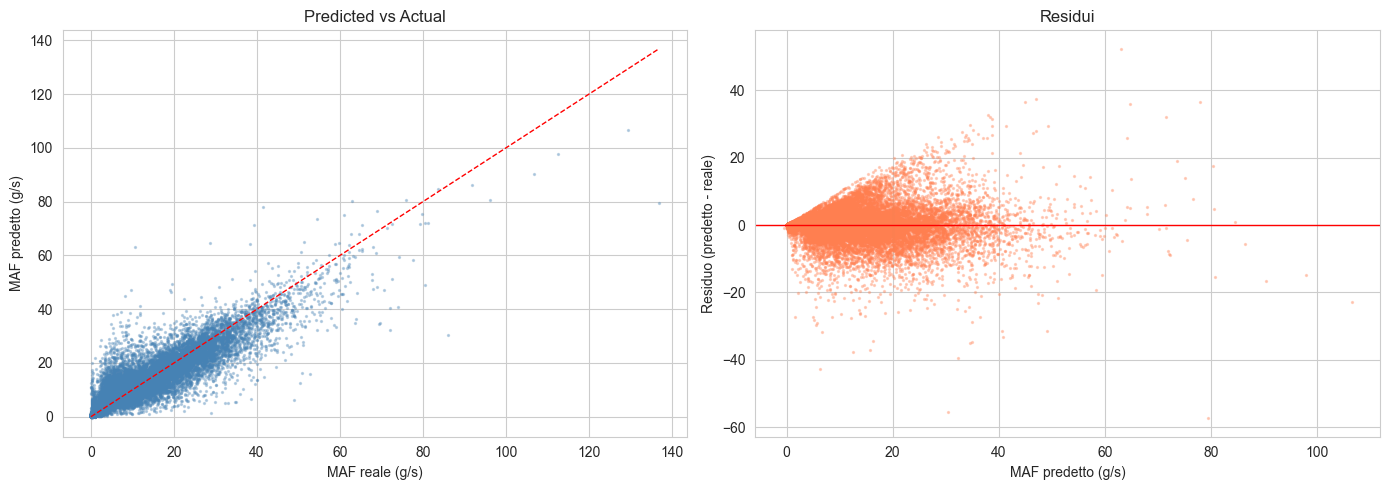

Residuo medio: 0.1433
Residuo std:   4.1308


In [17]:
# Campiona per leggibilità
idx = np.random.RandomState(RANDOM_STATE).choice(len(y_test), size=min(30000, len(y_test)), replace=False)
y_t = y_test.iloc[idx]
y_p = y_pred_xgb[idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_t, y_p, s=2, alpha=0.3, color='steelblue')
lim = max(y_t.max(), y_p.max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=1)
axes[0].set_xlabel('MAF reale (g/s)')
axes[0].set_ylabel('MAF predetto (g/s)')
axes[0].set_title('Predicted vs Actual')

residuals = y_p - y_t
axes[1].scatter(y_p, residuals, s=2, alpha=0.3, color='coral')
axes[1].axhline(0, color='red', lw=1)
axes[1].set_xlabel('MAF predetto (g/s)')
axes[1].set_ylabel('Residuo (predetto - reale)')
axes[1].set_title('Residui')

plt.tight_layout()
plt.show()

print(f"Residuo medio: {residuals.mean():.4f}")
print(f"Residuo std:   {residuals.std():.4f}")

## 17. Sezione narrativa — applicazione al cruise control adattivo

**L'idea:** prendere un trip reale e mostrare cosa farebbe un cruise control adattivo predittivo.

**Esperimento controfattuale:** prendiamo un trip esistente, e per ogni punto simuliamo "cosa succederebbe se invece di andare a velocità $v$ il veicolo andasse a velocità $v' = v \cdot k$?" — il modello ci dice il MAF predetto per quella velocità alternativa, mantenendo costanti pendenza, peso e contesto.

**Limite metodologico (importante da dichiarare):** stiamo facendo *controllo controfattuale* su un modello statistico, non simulazione fisica. Le predizioni in zone fuori dalla distribuzione del training set sono inaffidabili. Per uno studio reale serviebbe un simulatore veicolo. Qui è una dimostrazione *concettuale*.

In [18]:
# Scegliamo un trip dal test set con orografia interessante (almeno una salita)
test_trip_summary = test_df.groupby(['VehId', 'Trip']).agg(
    n=('MAF_g_per_sec', 'size'),
    elev_range=('elevation_m', lambda s: s.max() - s.min()),
    speed_avg=('Vehicle_Speed_km_per_h', 'mean')
).reset_index()

candidates = test_trip_summary[(test_trip_summary['n'].between(300, 1200))
                                & (test_trip_summary['elev_range'] > 20)
                                & (test_trip_summary['speed_avg'] > 20)]
veh_id, trip_id, *_ = candidates.sample(n=1, random_state=RANDOM_STATE).iloc[0]
veh_id, trip_id = int(veh_id), int(trip_id)

trip_data = test_df[(test_df['VehId']==veh_id) & (test_df['Trip']==trip_id)].sort_values('Timestampms').reset_index(drop=True)
trip_data['t_s'] = (trip_data['Timestampms'] - trip_data['Timestampms'].iloc[0]) / 1000
print(f"Selected: VehId={veh_id}, Trip={trip_id}, EngineType={trip_data['EngineType'].iloc[0]}, {len(trip_data)} righe")

Selected: VehId=393, Trip=3864, EngineType=HEV, 862 righe


In [19]:
# Predizione baseline (scenario reale)
X_real = trip_data[FEATURES_NUM + FEATURES_CAT]
maf_real_pred = pipe_xgb_final.predict(X_real)

# Scenario controfattuale: velocità ridotta del 10% (eco)
X_eco = X_real.copy()
X_eco['Vehicle_Speed_km_per_h'] = X_eco['Vehicle_Speed_km_per_h'] * 0.9
X_eco['speed_roll30s_mean'] = X_eco['speed_roll30s_mean'] * 0.9
X_eco['speed_future_5'] = X_eco['speed_future_5'] * 0.9
X_eco['speed_future_10'] = X_eco['speed_future_10'] * 0.9
maf_eco = pipe_xgb_final.predict(X_eco)

# Scenario: velocità aumentata del 10% (sport)
X_sport = X_real.copy()
X_sport['Vehicle_Speed_km_per_h'] = X_sport['Vehicle_Speed_km_per_h'] * 1.1
X_sport['speed_roll30s_mean'] = X_sport['speed_roll30s_mean'] * 1.1
X_sport['speed_future_5'] = X_sport['speed_future_5'] * 1.1
X_sport['speed_future_10'] = X_sport['speed_future_10'] * 1.1
maf_sport = pipe_xgb_final.predict(X_sport)

# Confronto consumi cumulativi (integrando MAF * dt)
dt_s = trip_data['dt_ms'].clip(lower=0, upper=2000) / 1000
g_real = (maf_real_pred * dt_s).cumsum()
g_eco  = (maf_eco * dt_s).cumsum()
g_sport = (maf_sport * dt_s).cumsum()

print(f"Consumo aria cumulato (trip {veh_id}/{trip_id}):")
print(f"  Reale:  {g_real.iloc[-1]:.0f} g")
print(f"  Eco:    {g_eco.iloc[-1]:.0f} g  ({(g_eco.iloc[-1]/g_real.iloc[-1]-1)*100:+.1f}%)")
print(f"  Sport:  {g_sport.iloc[-1]:.0f} g  ({(g_sport.iloc[-1]/g_real.iloc[-1]-1)*100:+.1f}%)")

Consumo aria cumulato (trip 393/3864):
  Reale:  2980 g
  Eco:    2944 g  (-1.2%)
  Sport:  3031 g  (+1.7%)


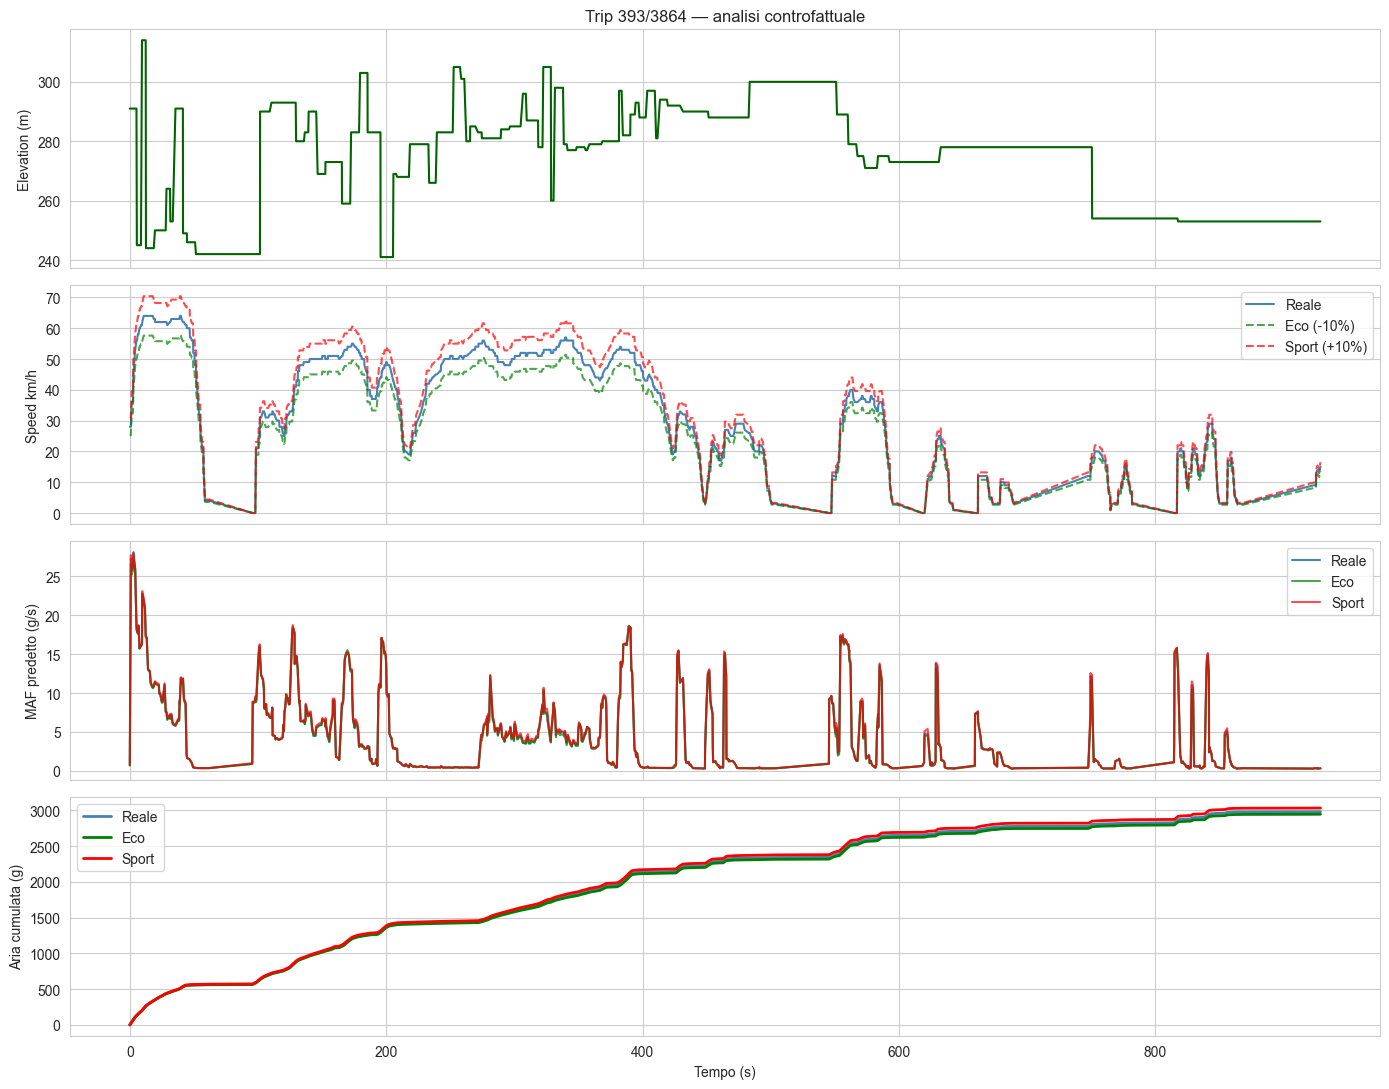

In [20]:
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

axes[0].plot(trip_data['t_s'], trip_data['elevation_m'], color='darkgreen', lw=1.5)
axes[0].set_ylabel('Elevation (m)')
axes[0].set_title(f'Trip {veh_id}/{trip_id} — analisi controfattuale')

axes[1].plot(trip_data['t_s'], trip_data['Vehicle_Speed_km_per_h'], label='Reale', color='steelblue')
axes[1].plot(trip_data['t_s'], trip_data['Vehicle_Speed_km_per_h']*0.9, label='Eco (-10%)', color='green', ls='--', alpha=0.7)
axes[1].plot(trip_data['t_s'], trip_data['Vehicle_Speed_km_per_h']*1.1, label='Sport (+10%)', color='red', ls='--', alpha=0.7)
axes[1].set_ylabel('Speed km/h')
axes[1].legend(loc='upper right')

axes[2].plot(trip_data['t_s'], maf_real_pred, label='Reale', color='steelblue')
axes[2].plot(trip_data['t_s'], maf_eco, label='Eco', color='green', alpha=0.7)
axes[2].plot(trip_data['t_s'], maf_sport, label='Sport', color='red', alpha=0.7)
axes[2].set_ylabel('MAF predetto (g/s)')
axes[2].legend(loc='upper right')

axes[3].plot(trip_data['t_s'], g_real, label='Reale', color='steelblue', lw=2)
axes[3].plot(trip_data['t_s'], g_eco, label='Eco', color='green', lw=2)
axes[3].plot(trip_data['t_s'], g_sport, label='Sport', color='red', lw=2)
axes[3].set_ylabel('Aria cumulata (g)')
axes[3].set_xlabel('Tempo (s)')
axes[3].legend(loc='upper left')

plt.tight_layout()
plt.show()

## 18. Salvataggio del modello finale

Salviamo il pipeline tunato così possiamo riusarlo (es. nel notebook 3 per arricchire i cluster, o in una demo).

In [21]:
import joblib
MODEL_PATH = Path("./outputs/xgb_maf_model.joblib")
joblib.dump(pipe_xgb_final, MODEL_PATH)
print(f"✓ Modello salvato: {MODEL_PATH} ({MODEL_PATH.stat().st_size/1e6:.1f} MB)")

# Salvataggio risultati
results_df.to_csv("./outputs/supervised_results.csv", index=False)
print("✓ Risultati salvati in supervised_results.csv")

✓ Modello salvato: outputs\xgb_maf_model.joblib (79.4 MB)
✓ Risultati salvati in supervised_results.csv


---

## Riepilogo finale

**Cosa abbiamo costruito:**
- Pipeline scikit-learn con ColumnTransformer (numeriche + categoriche)
- Confronto sistematico di 5 modelli: baseline mean, Ridge, Lasso, Random Forest, XGBoost default, XGBoost tuned
- Tuning bayesiano con Optuna su 8 iperparametri di XGBoost (50 trial)
- Cross-validation con GroupKFold per evitare leakage tra veicoli
- Feature engineering con look-ahead (la chiave del progetto)
- Split temporale rigoroso (trip futuri nel test set)
- Analisi controfattuale per dimostrare il valore del cruise control adattivo

**Limitazioni (da menzionare nella presentazione):**
- Il modello statistico non sostituisce un simulatore veicolo dinamico
- Lo scenario controfattuale assume che le altre variabili (RPM, load) restino invariate — in realtà cambierebbero con la velocità
- I dati coprono solo Ann Arbor: non generalizzano automaticamente ad altre aree
- Open-Meteo Elevation ha risoluzione ~30m: pendenze su tratti brevi sono approssimative

**Prossimo passo:** notebook 3 — clustering unsupervised dei tratti stradali, per scoprire categorie naturali di guida.